Imports


In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Cargar dataset


In [46]:
df = pd.read_excel("../data/Online Retail.xlsx", sheet_name=0)

# Exploring Patterns


Hemos incluido en este notebook una exploración del campo "InvoiceDate", un poco de cálculo de ganancias y exploración del campo "Country".


Hemos decidido separar esto porque al final no tuvo influencia en las decisiones que hemos tomado en la limpieza o en el clustering.


Lo armamos mientras fuimos conociendo el dataset.


### Limpieza básica


Si bien este notebook es exploratorio y previo a la limpieza, borramos algunos registros que pueden agregar ruido y arruinar la visualización de los datos.


Especificamente borramos:

- Registros sin "CustomerID".
- Registros con "Quantity" negativa.
- Registros con "UnitPrice" negativo o igual a cero.


In [47]:
df_clean = df.dropna(subset=["CustomerID"])
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

### Features temporales


Se nos ocurre explorar patrones temporales, extrayendo diferentes componentes de la fecha del campo "InvoiceDate".


In [52]:
# Se nos ocurren las siguientes
df_clean["year"] = df_clean["InvoiceDate"].dt.year  # Año
df_clean["month"] = df_clean["InvoiceDate"].dt.month  # Mes
df_clean["day"] = df_clean["InvoiceDate"].dt.day  # Día
df_clean["hour"] = df_clean["InvoiceDate"].dt.hour  # Hora
df_clean["dow"] = df_clean["InvoiceDate"].dt.dayofweek  # Día de la semana
df_clean["dow_name"] = df_clean[
    "InvoiceDate"
].dt.day_name()  # Nombre del día de la semana
df_clean["month_year"] = df_clean["InvoiceDate"].dt.to_period("M")  # Mes y año
df_clean["revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]  # Ingresos

In [6]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day,month,year,hour,day_of_week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,12,2010,8,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,12,2010,8,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,12,2010,8,2


##### Mensual


Podríamos ver la evolución de las ventas a lo largo del tiempo.


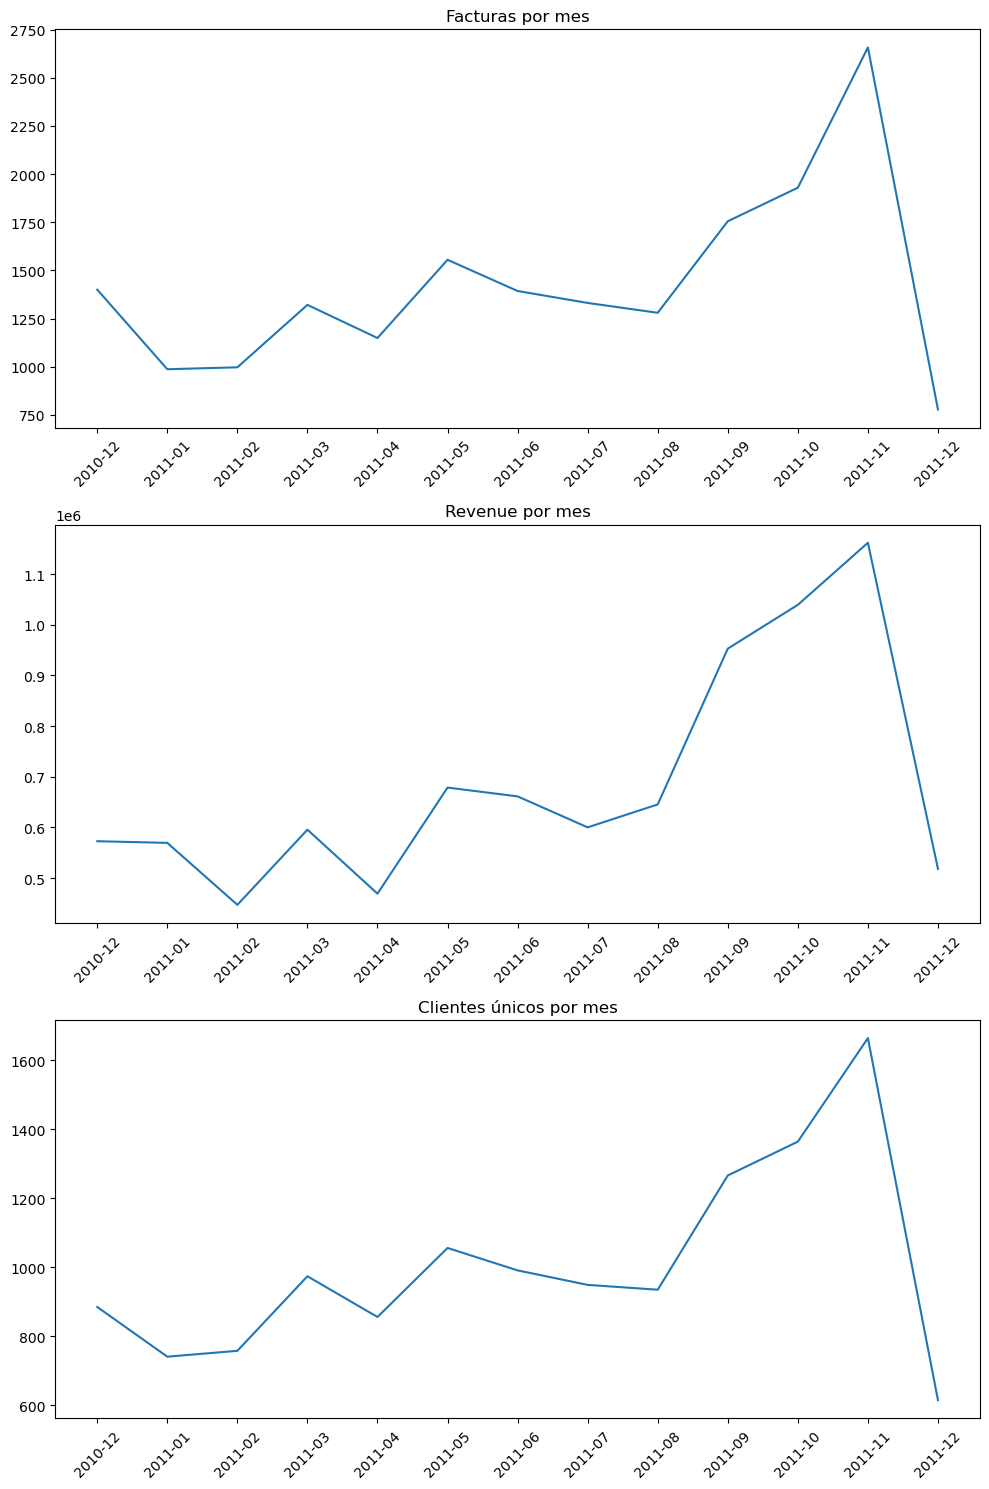

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

monthly = (
    df_clean.groupby("month_year")
    .agg({"InvoiceNo": "nunique", "revenue": "sum", "CustomerID": "nunique"})
    .reset_index()
)
monthly["month_str"] = monthly["month_year"].astype(str)

axes[0].plot(monthly["month_str"], monthly["InvoiceNo"])
axes[0].set_title("Facturas por mes")

axes[1].plot(monthly["month_str"], monthly["revenue"])
axes[1].set_title("Revenue por mes")

axes[2].plot(monthly["month_str"], monthly["CustomerID"])
axes[2].set_title("Clientes únicos por mes")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Podemos observar varios patrones de los gráficos de arriba.


- Hay un claro patrón con picos en los últimos meses del año, especialmente en Noviembre. Creemos que se debe por compras previas a Navidad.


- También vemos un crecimiento sostenido a lo largo de 2011. Dejando de lado este pico por Navidad. Interpretamos esto como que el negocio se está expandiendo y aumenta el número de ventas, ganancia y clientes únicos.


##### Semanal


Queremos ver si hay algún patrón relacionado al día de la semana.


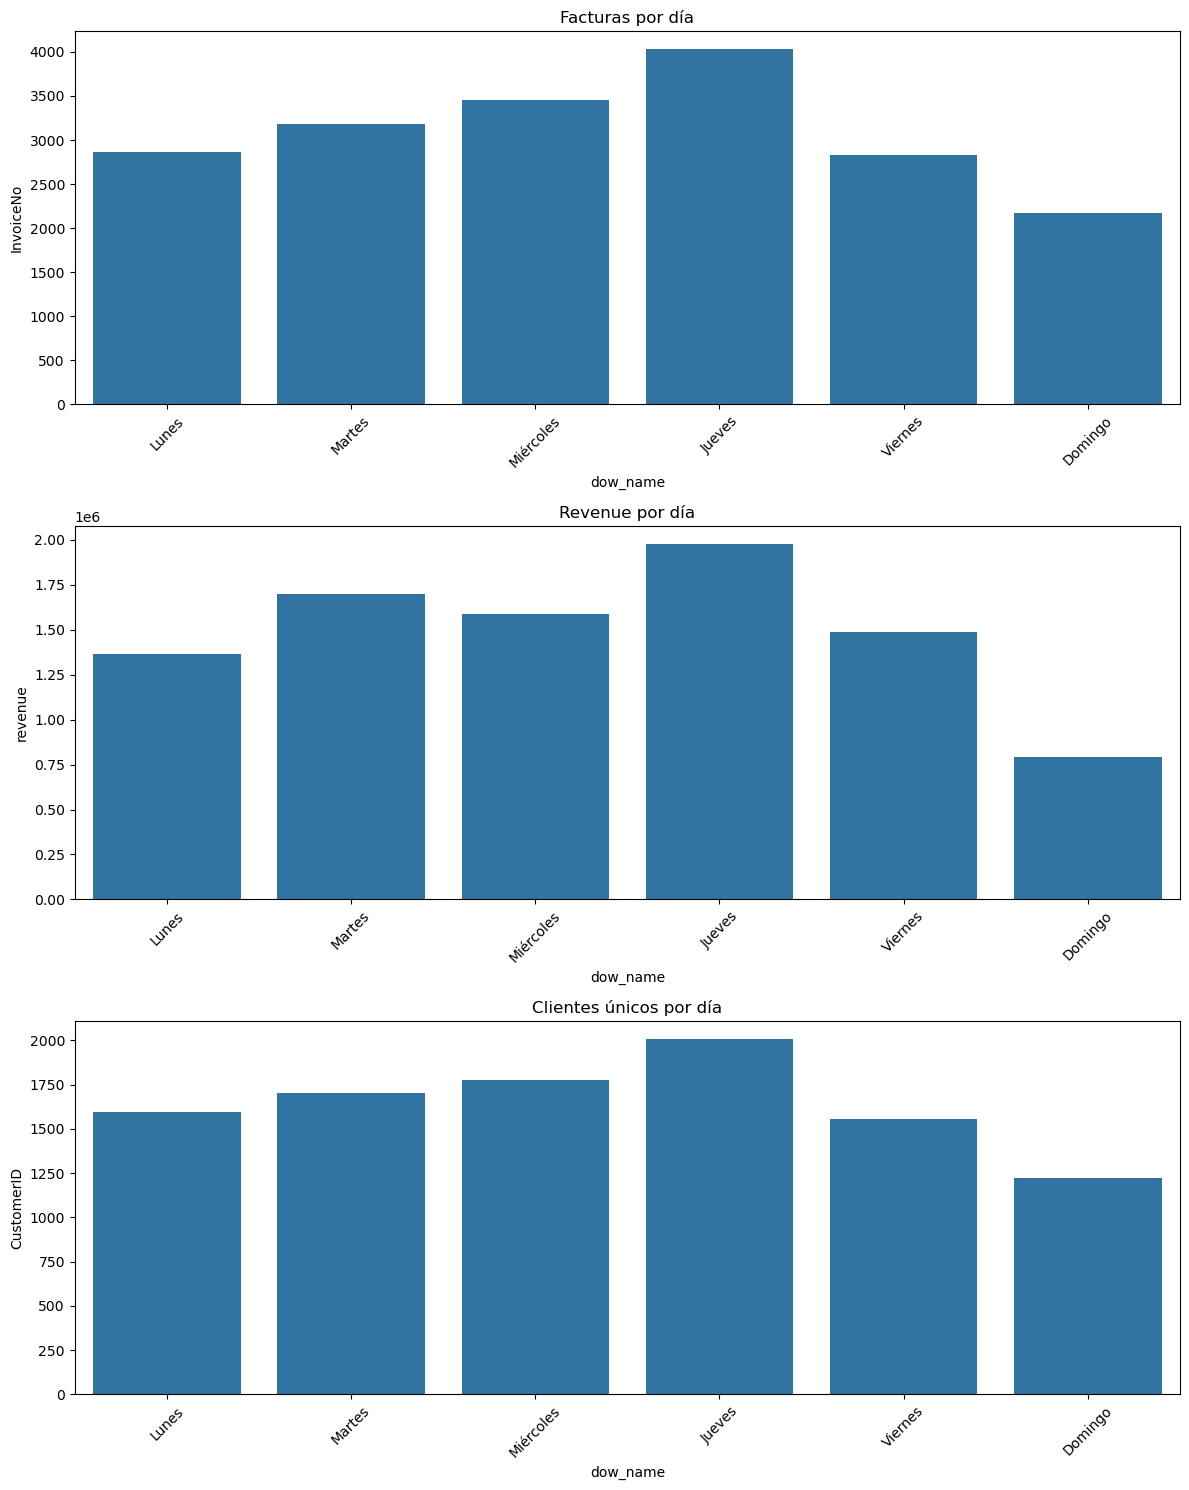

In [ ]:
day_map = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

by_day = (
    df_clean.groupby("dow")
    .agg({"InvoiceNo": "nunique", "revenue": "sum", "CustomerID": "nunique"})
    .reset_index()
)

by_day["dow_name"] = by_day["dow"].map(day_map)

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(data=by_day, x="dow_name", y="InvoiceNo", ax=axes[0])
axes[0].set_title("Facturas por día")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=by_day, x="dow_name", y="revenue", ax=axes[1])
axes[1].set_title("Revenue por día")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=by_day, x="dow_name", y="CustomerID", ax=axes[2])
axes[2].set_title("Clientes únicos por día")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Observamos lo siguiente:


- No hay facturas los días sábados. Desconocemos la razón detrás de esto.


- El jueves es el día pico en todas las métricas.


- Distribución bastante equilibrada durante los días hábiles. El domingo es ligeramente inferior en todas las métricas al resto de días.


##### Horario


También podemos indagar en la distribución de las ventas a lo largo de las diferentes horas del día.


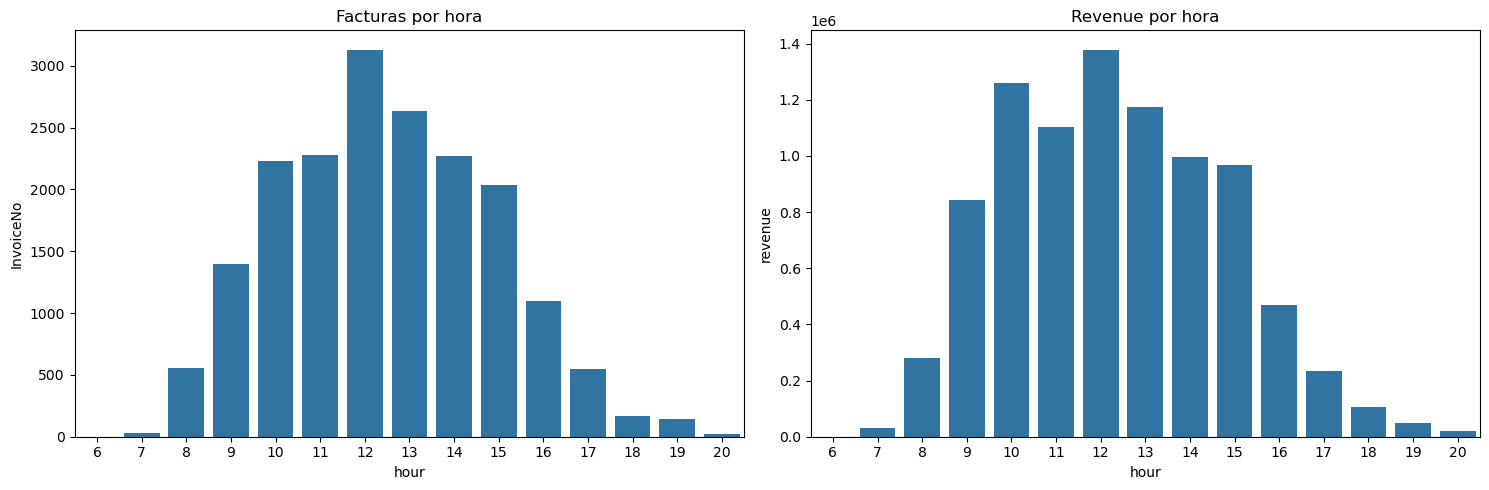

In [61]:
by_hour = (
    df_clean.groupby("hour")
    .agg({"InvoiceNo": "nunique", "revenue": "sum", "CustomerID": "nunique"})
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=by_hour, x="hour", y="InvoiceNo", ax=axes[0])
axes[0].set_title("Facturas por hora")

sns.barplot(data=by_hour, x="hour", y="revenue", ax=axes[1])
axes[1].set_title("Revenue por hora")

plt.tight_layout()
plt.show()

Observamos que:


- Las compras se concentran principalmente entre las 9:00 y las 17:00 horas. Lo que parece un horario de oficina estándar.


- Hay un pico de actividad entre las 12:00 y las 14:00. Esto podría ser el horario preferido para coordinar con los clientes mayoristas de esta tienda.


- No hay transacciones fuera del horario comercial, por lo que no parece ser un e-commerce 24/7


##### Geografía


También nos gustaría entender mejor la distribución geográfica de los clientes.


/var/folders/1m/bk2lcr5d2p59b73zyk_lvr000000gn/T/ipykernel_34978/1045987027.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_countries["avg_rev_per_customer"] = (


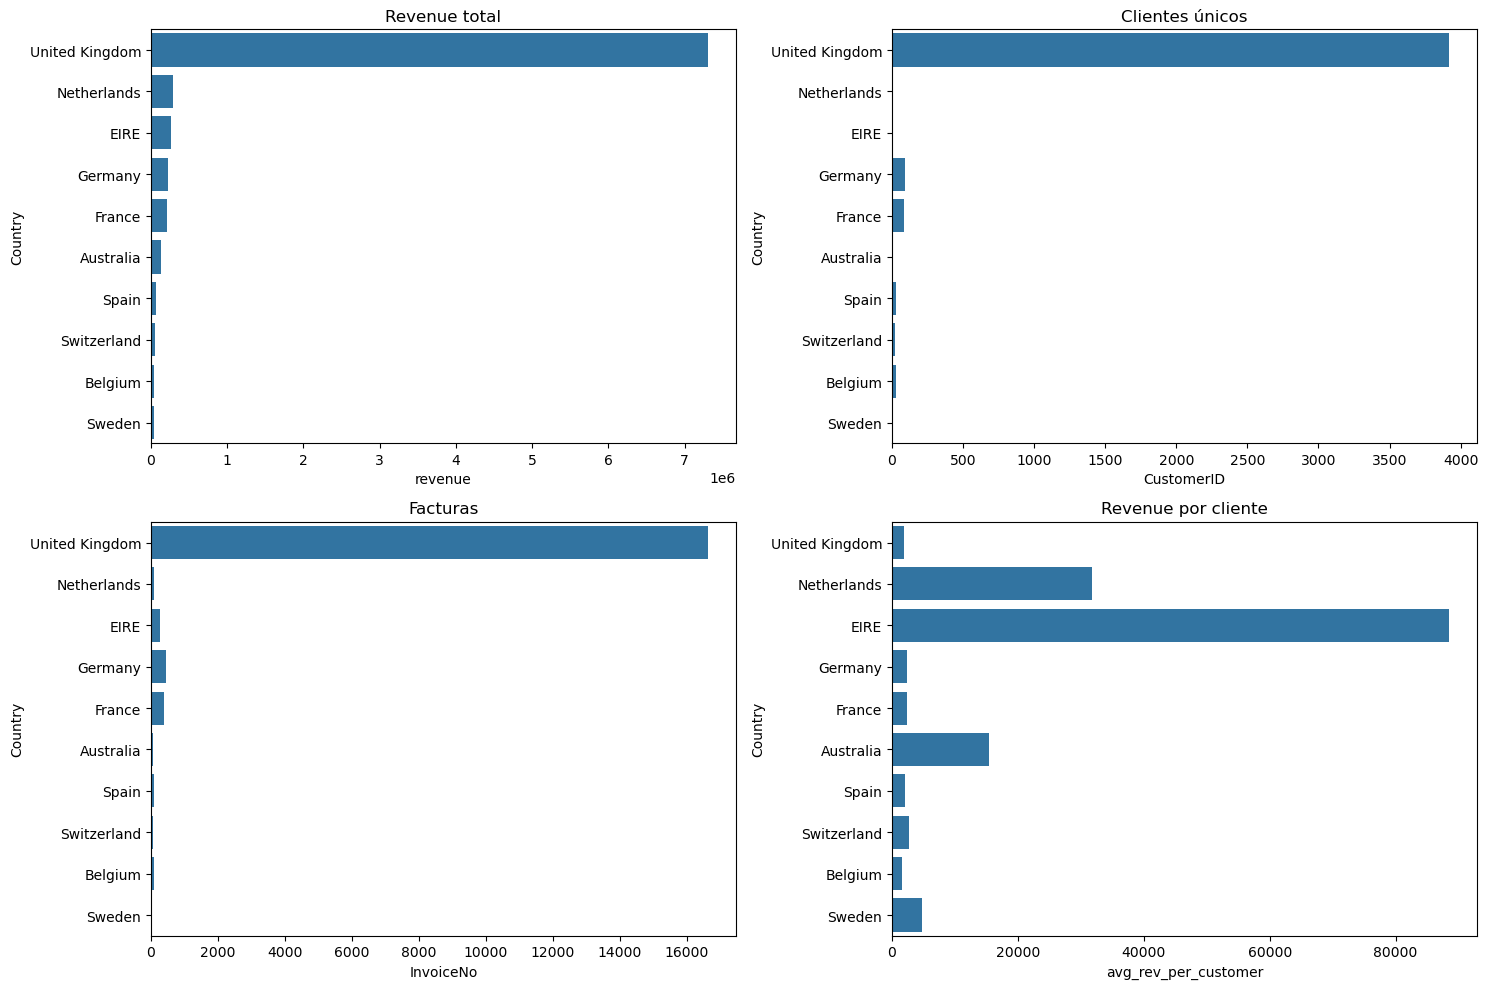

In [62]:
by_country = (
    df_clean.groupby("Country")
    .agg(
        {
            "CustomerID": "nunique",
            "InvoiceNo": "nunique",
            "revenue": "sum",
            "Quantity": "sum",
        }
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

top_countries = by_country.head(10)
top_countries["avg_rev_per_customer"] = (
    top_countries["revenue"] / top_countries["CustomerID"]
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=top_countries, x="revenue", y="Country", ax=axes[0, 0])
axes[0, 0].set_title("Revenue total")

sns.barplot(data=top_countries, x="CustomerID", y="Country", ax=axes[0, 1])
axes[0, 1].set_title("Clientes únicos")

sns.barplot(data=top_countries, x="InvoiceNo", y="Country", ax=axes[1, 0])
axes[1, 0].set_title("Facturas")

sns.barplot(data=top_countries, x="avg_rev_per_customer", y="Country", ax=axes[1, 1])
axes[1, 1].set_title("Revenue por cliente")

plt.tight_layout()
plt.show()

- Vemos que UK domina en casi todas las métricas. Es el país con más facturas, con más ganancia total, y con más clientes únicos.


- Del resto de países, figuran Alemania y Francia como los siguientes mercados más importantes. Capaz que la estrategia de esta tienda es expandirse por Europa.


- UK no tiene la mayor ganancia por cliente. Lo que podría indicar que hay mercados a los que se dirigen productos más caros, o que hay clientes mayoristas más grandes ahí.


##### UK vs el mundo


Como vimos que UK destaca tanto en las diferentes métricas que visualizamos, queremos compararlo con el resto del mundo en conjunto, para entender mejor las diferencias.


> En la descripción del dataset, y al comienzo de nuestro notebook de preprocesamiento, aclaramos que las unidades monetarias están expresadas en libras esterlinas.


In [63]:
uk = df_clean[df_clean["Country"] == "United Kingdom"]
non_uk = df_clean[df_clean["Country"] != "United Kingdom"]

print(f"UK - Clientes: {uk['CustomerID'].nunique()}")
print(f"No UK - Clientes: {non_uk['CustomerID'].nunique()}")
print(f"UK - Revenue: £{uk['revenue'].sum():,.2f}")
print(f"No UK - Revenue: £{non_uk['revenue'].sum():,.2f}")
print(
    f"UK representa: {uk['revenue'].sum() / df_clean['revenue'].sum() * 100:.1f}% del revenue total"
)

UK - Clientes: 3920
No UK - Clientes: 418
UK - Revenue: £7,308,391.55
No UK - Revenue: £1,603,016.35
UK representa: 82.0% del revenue total


- El mercado local representa más del 80% de la ganancia total. Esto nos da a entender que la empresa es fundamentalmente británica, y que las operacoines internacionales son secundarias.


##### Estructura de Precios


También queremos pegar un vistazo a la distribución de los precios.


count    397884.000000
mean          3.116488
std          22.097877
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64


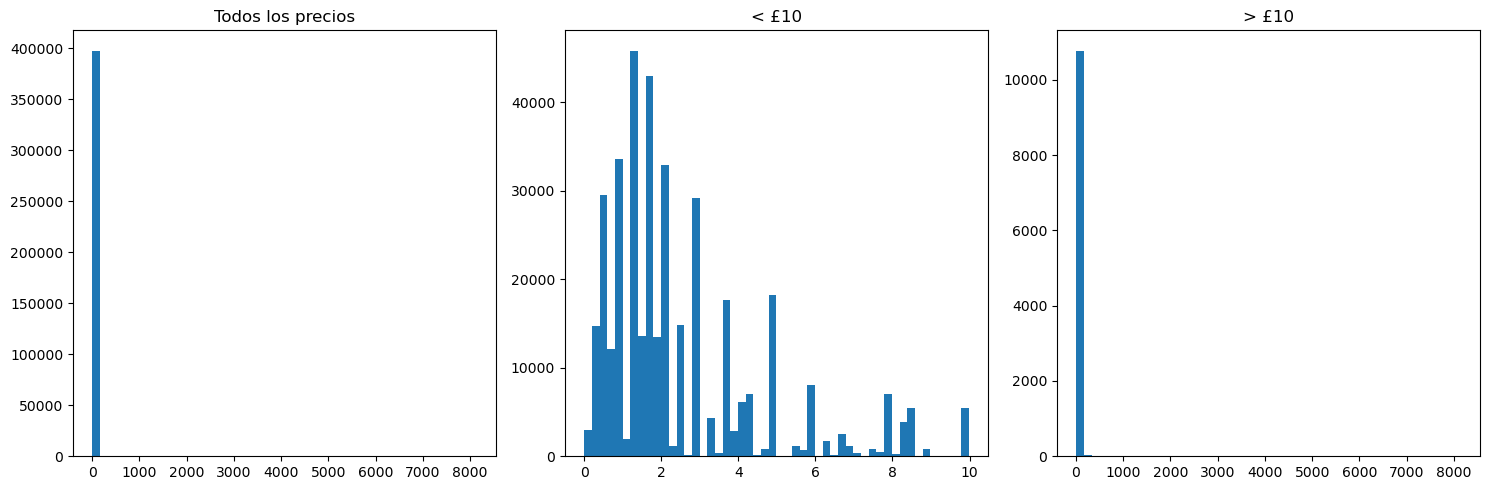

In [64]:
print(df_clean["UnitPrice"].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df_clean["UnitPrice"], bins=50)
axes[0].set_title("Todos los precios")

axes[1].hist(df_clean[df_clean["UnitPrice"] < 10]["UnitPrice"], bins=50)
axes[1].set_title("< £10")

axes[2].hist(df_clean[df_clean["UnitPrice"] > 10]["UnitPrice"], bins=50)
axes[2].set_title("> £10")

plt.tight_layout()
plt.show()

- La mayoría de los productos son económicos, con una media de 3,11.


- Está sesgado hacia precios bajos, parece que la tienda se basa en productos de precio accesible.


- Existen productos más premium, con un precio mayor a 10$, pero representan una fracción menor del volumen total.


Dada la gran cantidad de productos de bajo precio, creemos que entonces el volumen de las transacciones es crucial para este negocio.


##### El segmento premium


Profundicemos un poco en los productos de mayor valor.


In [65]:
expensive = df_clean[df_clean["UnitPrice"] > 50]
print(f"Transacciones > £50: {len(expensive)}")
print(f"Productos únicos caros: {expensive['Description'].nunique()}")

top_expensive = (
    expensive.groupby("Description")
    .agg({"UnitPrice": "mean", "Quantity": "sum", "revenue": "sum"})
    .reset_index()
    .sort_values("UnitPrice", ascending=False)
)

print(top_expensive.head(10))

Transacciones > £50: 241
Productos únicos caros: 14
                           Description   UnitPrice  Quantity   revenue
5                               Manual  996.504490        50  49104.32
3                       DOTCOM POSTAGE  912.736154        13  11865.57
7                              POSTAGE  845.049286        22  12510.69
6       PICNIC BASKET WICKER 60 PIECES  649.500000        61  39619.50
9   RUSTIC  SEVENTEEN DRAWER SIDEBOARD  158.076923        35   5415.00
8         REGENCY MIRROR WITH SHUTTERS  156.428571        10   1530.00
11        VINTAGE BLUE KITCHEN CABINET  151.842105        25   3635.00
0                             CARRIAGE  150.000000         1    150.00
13         VINTAGE RED KITCHEN CABINET  148.611111        57   7975.00
1        CHEST NATURAL WOOD 20 DRAWERS  118.076923        24   2745.00


Con lo que aprendimos en el análisis de "StockCode", podemos afirmar que los primeros tres productos que figuran arriba no son relevantes, pues no representan compras que nos interesen para el análisis.


---


Aquí termina lo que fue nuestra exploración de estos campos. Como dijimos: no tuvo una relevancia considerable al momento de tomar decisiones en la limpieza o en el análisis. Pero fue parte del proceso de ir entendiendo el dataset.
